In [1]:
 # 1. Import Dependencies
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import random
import matplotlib.pyplot as plt


In [3]:
# 2. Data Loading and Preprocessing
df = pd.read_csv("extracted_columns.csv")

X = df[['PSS-1', 'PSS-2', 'PSS-3', 'PSS-4', 'PSS-5', 'PSS-6', 'PSS-7', 
        'PSS-8', 'PSS-9', 'PSS-10', 'PSS-11', 'PSS-12', 'PSS-13', 'PSS-14']]
df['PSS_total'] = X.sum(axis=1)
y = df['PSS_total']


In [5]:
# 4. Random Forest Implementation
# Parameter bounds for Random Forest hyperparameters
rfr_param_bounds = {
    'n_estimators': [50, 200],
    'max_depth': [None, 5, 10, 20, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

def create_rfr_individual():
    return {
        'n_estimators': int(random.uniform(rfr_param_bounds['n_estimators'][0], rfr_param_bounds['n_estimators'][1])),
        'max_depth': random.choice(rfr_param_bounds['max_depth']),
        'min_samples_split': int(random.uniform(rfr_param_bounds['min_samples_split'][0], rfr_param_bounds['min_samples_split'][1])),
        'min_samples_leaf': int(random.uniform(rfr_param_bounds['min_samples_leaf'][0], rfr_param_bounds['min_samples_leaf'][1]))
    }

def mutate_rfr(individual, mutation_rate=0.1):
    if random.random() < mutation_rate:
        individual['n_estimators'] = int(np.clip(individual['n_estimators'] + random.randint(-10, 10), rfr_param_bounds['n_estimators'][0], rfr_param_bounds['n_estimators'][1]))
    if random.random() < mutation_rate:
        choices = [d for d in rfr_param_bounds['max_depth'] if d != individual['max_depth']]
        if choices:
            individual['max_depth'] = random.choice(choices)
    if random.random() < mutation_rate:
        individual['min_samples_split'] = int(np.clip(individual['min_samples_split'] + random.randint(-1, 1), rfr_param_bounds['min_samples_split'][0], rfr_param_bounds['min_samples_split'][1]))
    if random.random() < mutation_rate:
        individual['min_samples_leaf'] = int(np.clip(individual['min_samples_leaf'] + random.randint(-1, 1), rfr_param_bounds['min_samples_leaf'][0], rfr_param_bounds['min_samples_leaf'][1]))
    return individual

def fitness_rfr_kfold(individual, X, y, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    rmse_scores = []
    for train_index, val_index in kf.split(X):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]
        model = make_pipeline(
            StandardScaler(),
            RandomForestRegressor(
                n_estimators=individual['n_estimators'],
                max_depth=individual['max_depth'],
                min_samples_split=individual['min_samples_split'],
                min_samples_leaf=individual['min_samples_leaf'],
                random_state=42
            )
        )
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
    return -np.mean(rmse_scores)

def genetic_algorithm_rfr_kfold(X, y, generations=10, population_size=20, k=5):
    population = [create_rfr_individual() for _ in range(population_size)]
    for individual in population:
        individual['fitness'] = fitness_rfr_kfold(individual, X, y, k=k)
    for gen in range(generations):
        new_population = []
        while len(new_population) < population_size:
            parent1 = random.choice(population)
            parent2 = random.choice(population)
            child = {}
            for key in parent1.keys():
                if key != 'fitness':
                    child[key] = parent1[key] if random.random() > 0.5 else parent2[key]
            child = mutate_rfr(child)
            child['fitness'] = fitness_rfr_kfold(child, X, y, k=k)
            new_population.append(child)
        population = new_population
        best = max(population, key=lambda x: x['fitness'])
        print(f"Generation {gen+1}, Best RMSE: {-best['fitness']:.4f}, Params: {best}")
    best_individual = max(population, key=lambda x: x['fitness'])
    return best_individual


In [30]:
# Run the genetic algorithm with k-fold validation
best_params_kfold = genetic_algorithm_rfr_kfold(X, y)

Generation 1, Best RMSE: 1.8742, Params: {'n_estimators': 171, 'max_depth': 20, 'min_samples_split': 3, 'min_samples_leaf': 1, 'fitness': np.float64(-1.8741729338230484)}
Generation 2, Best RMSE: 1.8645, Params: {'n_estimators': 188, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'fitness': np.float64(-1.8645463370857844)}
Generation 3, Best RMSE: 1.8645, Params: {'n_estimators': 188, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'fitness': np.float64(-1.8645463370857844)}
Generation 4, Best RMSE: 1.8621, Params: {'n_estimators': 195, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'fitness': np.float64(-1.8620788107735549)}
Generation 5, Best RMSE: 1.8645, Params: {'n_estimators': 188, 'max_depth': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'fitness': np.float64(-1.8645463370857844)}
Generation 6, Best RMSE: 1.8638, Params: {'n_estimators': 188, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 1, 'fitness': np.floa

In [29]:
# Train the final model on the full dataset using best hyperparameters
final_model = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(
        n_estimators=best_params_kfold['n_estimators'],
        max_depth=best_params_kfold['max_depth'],
        min_samples_split=best_params_kfold['min_samples_split'],
        min_samples_leaf=best_params_kfold['min_samples_leaf'],
        random_state=42
    )
)
final_model.fit(X, y)

,steps,"[('standardscaler', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,155
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2


GA-Optimized RFR with KFold and Pipeline RMSE: 0.7090
GA-Optimized RFR with KFold and Pipeline MAE: 0.5328
GA-Optimized RFR with KFold and Pipeline R^2: 0.9912


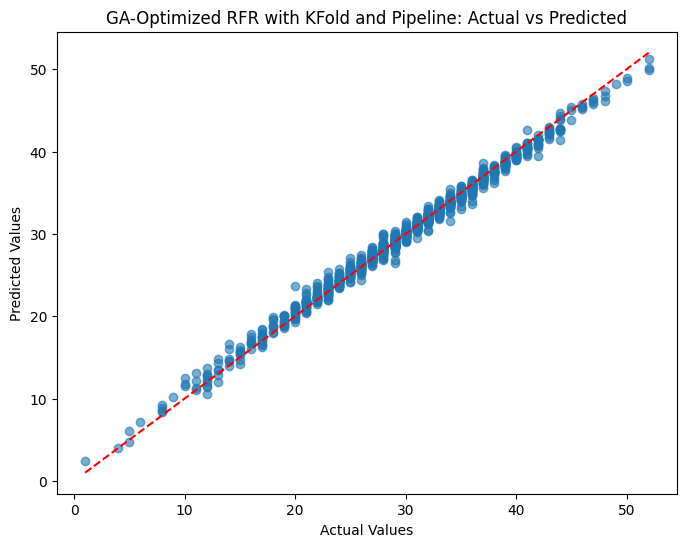

In [31]:
# Get predictions from the trained pipeline model
y_pred = final_model.predict(X)

# Define the evaluation and plotting function
def evaluate_and_plot(model_name, y_true, y_pred):
    import matplotlib.pyplot as plt
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    import numpy as np

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{model_name} RMSE: {rmse:.4f}")
    print(f"{model_name} MAE: {mae:.4f}")
    print(f"{model_name} R^2: {r2:.4f}")
    
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'{model_name}: Actual vs Predicted')
    plt.show()

# Call the evaluation and plotting function
evaluate_and_plot('GA-Optimized RFR with KFold and Pipeline', y, y_pred)
